In [1]:
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
from matplotlib.patches import Arc

RANDOM_SEED = 694973
pd.set_option('display.max_columns', None)

In [2]:
from typing import Union

def define_index(data: pd.DataFrame, label: str) -> Union[np.array, dict]:
    """Defines an index variable starting at 1. We add 1 so '0' can act as a placeholder for
    any global optionality
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    data[label] = data[label].apply(str)
    unq_ids = data[label].unique()
    n_ids = len(unq_ids)
    lookup_dict = dict(zip(unq_ids, range(n_ids)))
    return data[label].replace(lookup_dict).values + 1, lookup_dict


def map_index(data: pd.DataFrame, label: str, lookup_dict: dict) -> np.array:
    """Applies an index to new values
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format
        lookup_dict (dict): dictionary that contains the mappings from inputs to index

    Returns:
        np.array: indexed values
    """
    data[label] = data[label].apply(str)
    vals = pd.to_numeric(np.where(data[label].isin(list(lookup_dict.keys())), data[label].replace(lookup_dict).values, -1))
    return vals + 1

In [3]:
df=pd.read_csv('input/data.csv')
df.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,GAME_ID,homeTeamId,homeTeamTricode,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,SEASON
0,22200001,7,PT11M38.00S,1,1610612755,PHI,203954,Embiid,J. Embiid,-118,50,13,Missed,1,NaN,NaN,0,v,MISS Embiid 13' Turnaround Fadeaway Shot,Missed Shot,Turnaround Fadeaway shot,1,2,3,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23
1,22200001,11,PT11M15.00S,1,1610612738,BOS,203935,Smart,M. Smart,120,55,13,Made,1,2.0,0.0,2,h,Smart 13' Driving Floating Bank Jump Shot (2 PTS),Made Shot,Driving Floating Bank Jump Shot,1,2,7,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23
2,22200001,12,PT11M05.00S,1,1610612755,PHI,202699,Harris,T. Harris,50,135,14,Missed,1,NaN,NaN,0,v,MISS Harris 14' Driving Floating Jump Shot,Missed Shot,Driving Floating Jump Shot,1,2,8,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23
3,22200001,14,PT11M03.00S,1,1610612755,PHI,202699,Harris,T. Harris,0,0,0,Made,1,2.0,2.0,4,v,Harris Tip Layup Shot (2 PTS),Made Shot,Tip Layup Shot,1,2,10,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23
4,22200001,15,PT10M46.00S,1,1610612738,BOS,1628369,Tatum,J. Tatum,-232,49,24,Made,1,5.0,2.0,7,h,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),Made Shot,Jump Shot,1,3,11,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23


In [4]:
print(df.shape)

(512943, 32)


In [5]:
# remove any games that have a missing home or away team ID
missing_ids=df.loc[(df['homeTeamId'].isna())|(df['awayTeamId'].isna())]
missing_game_ids = missing_ids['gameId']
df = df.loc[~df['gameId'].isin(missing_game_ids)]
print(df.shape)

(512026, 32)


In [6]:
len(pd.unique(missing_game_ids))

5

In [7]:
# recode clock into minutes + fractional seconds
parsed = df["clock"].str.extract(r"PT(?:(\d+)M)?(?:(\d+(?:\.\d+)?)S)?")
df["minutes"] = parsed[0].fillna(0).astype(int)
df["seconds"] = parsed[1].fillna(0).astype(float)
df['time_seconds'] = df['seconds']+df['minutes']*60
df['time_minutes'] = df['minutes'] + df['seconds']/60
df.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,GAME_ID,homeTeamId,homeTeamTricode,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,SEASON,minutes,seconds,time_seconds,time_minutes
0,22200001,7,PT11M38.00S,1,1610612755,PHI,203954,Embiid,J. Embiid,-118,50,13,Missed,1,NaN,NaN,0,v,MISS Embiid 13' Turnaround Fadeaway Shot,Missed Shot,Turnaround Fadeaway shot,1,2,3,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,38.0,698.0,11.633333
1,22200001,11,PT11M15.00S,1,1610612738,BOS,203935,Smart,M. Smart,120,55,13,Made,1,2.0,0.0,2,h,Smart 13' Driving Floating Bank Jump Shot (2 PTS),Made Shot,Driving Floating Bank Jump Shot,1,2,7,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,15.0,675.0,11.250000
2,22200001,12,PT11M05.00S,1,1610612755,PHI,202699,Harris,T. Harris,50,135,14,Missed,1,NaN,NaN,0,v,MISS Harris 14' Driving Floating Jump Shot,Missed Shot,Driving Floating Jump Shot,1,2,8,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,5.0,665.0,11.083333
3,22200001,14,PT11M03.00S,1,1610612755,PHI,202699,Harris,T. Harris,0,0,0,Made,1,2.0,2.0,4,v,Harris Tip Layup Shot (2 PTS),Made Shot,Tip Layup Shot,1,2,10,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,3.0,663.0,11.050000
4,22200001,15,PT10M46.00S,1,1610612738,BOS,1628369,Tatum,J. Tatum,-232,49,24,Made,1,5.0,2.0,7,h,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),Made Shot,Jump Shot,1,3,11,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,10,46.0,646.0,10.766667


In [8]:
# produce a new action ID
df = df.sort_values(['gameId', 'period', 'time_seconds'], ascending=[True, True, False])
df['event_id'] = df.groupby('gameId').cumcount()
df.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,GAME_ID,homeTeamId,homeTeamTricode,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,SEASON,minutes,seconds,time_seconds,time_minutes,event_id
0,22200001,7,PT11M38.00S,1,1610612755,PHI,203954,Embiid,J. Embiid,-118,50,13,Missed,1,NaN,NaN,0,v,MISS Embiid 13' Turnaround Fadeaway Shot,Missed Shot,Turnaround Fadeaway shot,1,2,3,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,38.0,698.0,11.633333,0
1,22200001,11,PT11M15.00S,1,1610612738,BOS,203935,Smart,M. Smart,120,55,13,Made,1,2.0,0.0,2,h,Smart 13' Driving Floating Bank Jump Shot (2 PTS),Made Shot,Driving Floating Bank Jump Shot,1,2,7,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,15.0,675.0,11.250000,1
2,22200001,12,PT11M05.00S,1,1610612755,PHI,202699,Harris,T. Harris,50,135,14,Missed,1,NaN,NaN,0,v,MISS Harris 14' Driving Floating Jump Shot,Missed Shot,Driving Floating Jump Shot,1,2,8,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,5.0,665.0,11.083333,2
3,22200001,14,PT11M03.00S,1,1610612755,PHI,202699,Harris,T. Harris,0,0,0,Made,1,2.0,2.0,4,v,Harris Tip Layup Shot (2 PTS),Made Shot,Tip Layup Shot,1,2,10,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,3.0,663.0,11.050000,3
4,22200001,15,PT10M46.00S,1,1610612738,BOS,1628369,Tatum,J. Tatum,-232,49,24,Made,1,5.0,2.0,7,h,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),Made Shot,Jump Shot,1,3,11,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,10,46.0,646.0,10.766667,4


In [9]:
# if first shot and cell is empty, make it zero; else use given score
df['scoreHome_mod']=np.where((df['event_id']==0)&(df['scoreHome'].isna()),0,df['scoreHome'])
df['scoreAway_mod']=np.where((df['event_id']==0)&(df['scoreAway'].isna()),0,df['scoreAway'])
df[['gameId','event_id','scoreHome','scoreAway','scoreHome_mod','scoreAway_mod']]

,gameId,event_id,scoreHome,scoreAway,scoreHome_mod,scoreAway_mod
0,22200001,0,NaN,NaN,0.0,0.0
1,22200001,1,2.0,0.0,2.0,0.0
2,22200001,2,NaN,NaN,NaN,NaN
3,22200001,3,2.0,2.0,2.0,2.0
4,22200001,4,5.0,2.0,5.0,2.0
...,...,...,...,...,...,...
512594,22401228,185,NaN,NaN,NaN,NaN
512595,22401228,186,NaN,NaN,NaN,NaN
512596,22401228,187,NaN,NaN,NaN,NaN
512597,22401228,188,NaN,NaN,NaN,NaN


In [10]:
# forward fill the score within game
df['scoreHome_mod_fill'] = df.groupby('gameId')['scoreHome_mod'].ffill()
df['scoreAway_mod_fill'] = df.groupby('gameId')['scoreAway_mod'].ffill()
df[['gameId','event_id','scoreHome','scoreAway','scoreHome_mod','scoreAway_mod','scoreHome_mod_fill','scoreAway_mod_fill']]

,gameId,event_id,scoreHome,scoreAway,scoreHome_mod,scoreAway_mod,scoreHome_mod_fill,scoreAway_mod_fill
0,22200001,0,NaN,NaN,0.0,0.0,0.0,0.0
1,22200001,1,2.0,0.0,2.0,0.0,2.0,0.0
2,22200001,2,NaN,NaN,NaN,NaN,2.0,0.0
3,22200001,3,2.0,2.0,2.0,2.0,2.0,2.0
4,22200001,4,5.0,2.0,5.0,2.0,5.0,2.0
...,...,...,...,...,...,...,...,...
512594,22401228,185,NaN,NaN,NaN,NaN,133.0,138.0
512595,22401228,186,NaN,NaN,NaN,NaN,133.0,138.0
512596,22401228,187,NaN,NaN,NaN,NaN,133.0,138.0
512597,22401228,188,NaN,NaN,NaN,NaN,133.0,138.0


In [11]:
# compute score differential
df['ishome_shooter']=np.where(df['teamId']==df['homeTeamId'],1,0)
df['score_shooter']=np.where(df['ishome_shooter']==1,df['scoreHome_mod_fill'],df['scoreAway_mod_fill'])
df['score_opposition']=np.where(df['ishome_shooter']==1,df['scoreAway_mod_fill'],df['scoreHome_mod_fill'])
df['score_diff']=df['score_shooter']-df['score_opposition']
df.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,GAME_ID,homeTeamId,homeTeamTricode,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,SEASON,minutes,seconds,time_seconds,time_minutes,event_id,scoreHome_mod,scoreAway_mod,scoreHome_mod_fill,scoreAway_mod_fill,ishome_shooter,score_shooter,score_opposition,score_diff
0,22200001,7,PT11M38.00S,1,1610612755,PHI,203954,Embiid,J. Embiid,-118,50,13,Missed,1,NaN,NaN,0,v,MISS Embiid 13' Turnaround Fadeaway Shot,Missed Shot,Turnaround Fadeaway shot,1,2,3,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,38.0,698.0,11.633333,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
1,22200001,11,PT11M15.00S,1,1610612738,BOS,203935,Smart,M. Smart,120,55,13,Made,1,2.0,0.0,2,h,Smart 13' Driving Floating Bank Jump Shot (2 PTS),Made Shot,Driving Floating Bank Jump Shot,1,2,7,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,15.0,675.0,11.250000,1,2.0,0.0,2.0,0.0,1,2.0,0.0,2.0
2,22200001,12,PT11M05.00S,1,1610612755,PHI,202699,Harris,T. Harris,50,135,14,Missed,1,NaN,NaN,0,v,MISS Harris 14' Driving Floating Jump Shot,Missed Shot,Driving Floating Jump Shot,1,2,8,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,5.0,665.0,11.083333,2,NaN,NaN,2.0,0.0,0,0.0,2.0,-2.0
3,22200001,14,PT11M03.00S,1,1610612755,PHI,202699,Harris,T. Harris,0,0,0,Made,1,2.0,2.0,4,v,Harris Tip Layup Shot (2 PTS),Made Shot,Tip Layup Shot,1,2,10,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,11,3.0,663.0,11.050000,3,2.0,2.0,2.0,2.0,0,2.0,2.0,0.0
4,22200001,15,PT10M46.00S,1,1610612738,BOS,1628369,Tatum,J. Tatum,-232,49,24,Made,1,5.0,2.0,7,h,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),Made Shot,Jump Shot,1,3,11,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23,10,46.0,646.0,10.766667,4,5.0,2.0,5.0,2.0,1,5.0,2.0,3.0


In [12]:
df.tail()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,GAME_ID,homeTeamId,homeTeamTricode,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,SEASON,minutes,seconds,time_seconds,time_minutes,event_id,scoreHome_mod,scoreAway_mod,scoreHome_mod_fill,scoreAway_mod_fill,ishome_shooter,score_shooter,score_opposition,score_diff
512594,22401228,656,PT01M52.00S,4,1610612742,DAL,1629023,Washington,P. Washington,-223,16,0,Missed,1,NaN,NaN,0,v,MISS Washington 3PT Jump Shot,Missed Shot,Jump Shot,1,3,454,22401228,1.610613e+09,GSW,1.610613e+09,DAL,NaN,NaN,2024-25,1,52.0,112.0,1.866667,185,NaN,NaN,133.0,138.0,0,138.0,133.0,5.0
512595,22401228,658,PT01M42.00S,4,1610612744,GSW,201939,Curry,S. Curry,190,200,28,Missed,1,NaN,NaN,0,h,MISS Curry 28' 3PT Pullup Jump Shot,Missed Shot,Pullup Jump shot,1,3,456,22401228,1.610613e+09,GSW,1.610613e+09,DAL,NaN,NaN,2024-25,1,42.0,102.0,1.700000,186,NaN,NaN,133.0,138.0,1,133.0,138.0,-5.0
512596,22401228,666,PT01M25.00S,4,1610612744,GSW,201939,Curry,S. Curry,127,255,28,Missed,1,NaN,NaN,0,h,MISS Curry 28' 3PT Jump Shot,Missed Shot,Jump Shot,1,3,462,22401228,1.610613e+09,GSW,1.610613e+09,DAL,NaN,NaN,2024-25,1,25.0,85.0,1.416667,187,NaN,NaN,133.0,138.0,1,133.0,138.0,-5.0
512597,22401228,678,PT01M01.00S,4,1610612744,GSW,1630322,Waters III,L. Waters III,-80,248,26,Missed,1,NaN,NaN,0,h,MISS Waters III 26' 3PT Jump Shot,Missed Shot,Jump Shot,1,3,470,22401228,1.610613e+09,GSW,1.610613e+09,DAL,NaN,NaN,2024-25,1,1.0,61.0,1.016667,188,NaN,NaN,133.0,138.0,1,133.0,138.0,-5.0
512598,22401228,700,PT00M33.00S,4,1610612744,GSW,1641764,Podziemski,B. Podziemski,28,66,7,Missed,1,NaN,NaN,0,h,MISS Podziemski 7' Driving Floating Jump Shot,Missed Shot,Driving Floating Jump Shot,1,2,484,22401228,1.610613e+09,GSW,1.610613e+09,DAL,NaN,NaN,2024-25,0,33.0,33.0,0.550000,189,NaN,NaN,133.0,138.0,1,133.0,138.0,-5.0


In [13]:
def define_defensive_team(homeTeamId, homeTeamTricode, awayTeamId, awayTeamTricode,ishome_shooter):
    if ishome_shooter==1:
        team_id = awayTeamId
        team_tri = awayTeamTricode
    else:
        team_id = homeTeamId
        team_tri = homeTeamTricode
    return team_id, team_tri

df[["defTeamId", "defTeamTricode"]] = df.apply(
    lambda row: define_defensive_team(
        row.homeTeamId,
        row.homeTeamTricode,
        row.awayTeamId,
        row.awayTeamTricode,
        row.ishome_shooter
    ),
    axis=1,
    result_type="expand"  # ensures the tuple is split into multiple columns
)
df[['teamTricode','homeTeamTricode','awayTeamTricode','playerNameI','ishome_shooter','defTeamId','defTeamTricode']]

,teamTricode,homeTeamTricode,awayTeamTricode,playerNameI,ishome_shooter,defTeamId,defTeamTricode
0,PHI,BOS,PHI,J. Embiid,0,1.610613e+09,BOS
1,BOS,BOS,PHI,M. Smart,1,1.610613e+09,PHI
2,PHI,BOS,PHI,T. Harris,0,1.610613e+09,BOS
3,PHI,BOS,PHI,T. Harris,0,1.610613e+09,BOS
4,BOS,BOS,PHI,J. Tatum,1,1.610613e+09,PHI
...,...,...,...,...,...,...,...
512594,DAL,GSW,DAL,P. Washington,0,1.610613e+09,GSW
512595,GSW,GSW,DAL,S. Curry,1,1.610613e+09,DAL
512596,GSW,GSW,DAL,S. Curry,1,1.610613e+09,DAL
512597,GSW,GSW,DAL,L. Waters III,1,1.610613e+09,DAL


<Axes: >

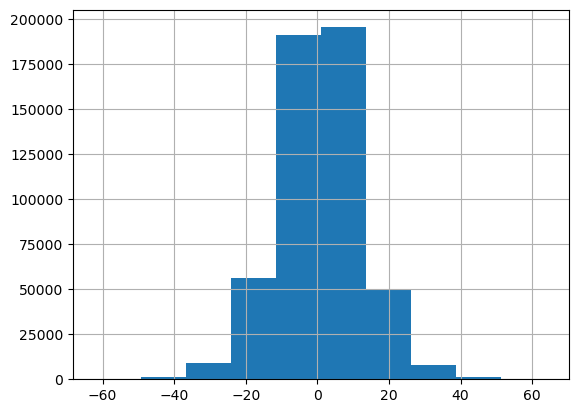

In [14]:
df['score_diff'].hist()

In [15]:
# codify shot type
layups = ['Tip Layup Shot','Driving Layup Shot','Running Layup Shot','Cutting Layup Shot','Driving Reverse Layup Shot','Layup Shot',
          'Driving Finger Roll Layup Shot','Running Reverse Layup Shot','Running Finger Roll Layup Shot','Alley Oop Layup shot','Putback Layup Shot',
          'Reverse Layup Shot','Finger Roll Layup Shot','Cutting Finger Roll Layup Shot','Running Alley Oop Layup Shot']
jumper = ['Jump Shot','Driving Floating Bank Jump Shot','Driving Floating Jump Shot','Fadeaway Jump Shot', 'Step Back Jump shot','Running Jump Shot',
          'Pullup Jump shot','Floating Jump shot','Running Pull-Up Jump Shot','Turnaround Fadeaway Bank Jump Shot', 'Jump Bank Shot', 'Turnaround Jump Shot','Step Back Bank Jump Shot',
          'Turnaround Fadeaway shot','Turnaround Bank shot','Fadeaway Bank shot'
          ]
dunk = ['Running Dunk Shot', 'Cutting Dunk Shot','Driving Dunk Shot','Putback Dunk Shot','Running Alley Oop Dunk Shot', 'Tip Dunk Shot', 'Dunk Shot',
        'Reverse Dunk Shot', 'Alley Oop Dunk Shot','Running Reverse Dunk Shot','Driving Reverse Dunk Shot',
        ]
hook = ['Hook Shot','Turnaround Bank Hook Shot','Turnaround Hook Shot', 'Driving Hook Shot', 'Hook Bank Shot','Driving Bank Hook Shot',]

df['shot_type'] = np.where(df['subType'].isin(layups),"LAYUP",'OTH')
df['shot_type'] = np.where(df['subType'].isin(jumper),"JUMPER",df['shot_type'])
df['shot_type'] = np.where(df['subType'].isin(dunk),"DUNK",df['shot_type'])
df['shot_type'] = np.where(df['subType'].isin(hook),"HOOK",df['shot_type'])
print(pd.unique(df['shot_type']))

['JUMPER' 'LAYUP' 'HOOK' 'DUNK']


In [16]:
# recode target variable to be 0 and 1
df['is_made'] = np.where(df['shotResult']=='Made',1,0)

In [17]:
df['SHOT_DISTANCE'] = np.sqrt((df["xLegacy"]/10)**2 + (df["yLegacy"]/10)**2)
df['ANGLE'] = np.degrees(np.arctan2(df['xLegacy'].abs(), df['yLegacy']))

df = df.loc[df['ANGLE']<=100]
df = df.loc[df['SHOT_DISTANCE']<=48] # one foot past halfway
df[['SHOT_DISTANCE', 'ANGLE']].describe()

,SHOT_DISTANCE,ANGLE
count,503749.000000,503749.000000
mean,14.268822,39.897339
std,10.444766,27.576192
min,0.000000,0.000000
25%,3.361547,17.145551
50%,13.340540,36.119341
75%,25.144582,60.255119
max,47.944656,99.981829


<Axes: >

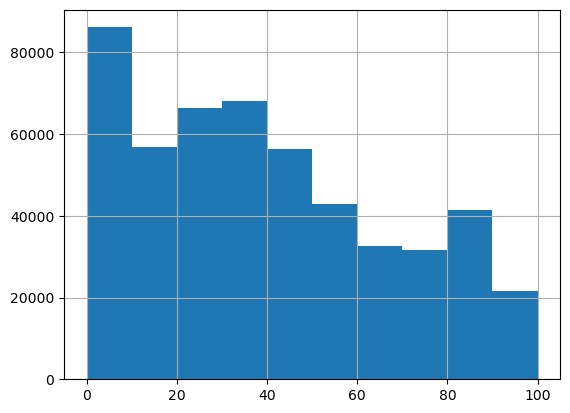

In [18]:
df['ANGLE'].hist()

<Axes: >

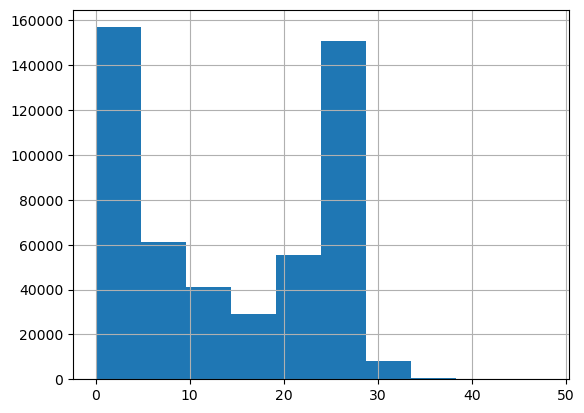

In [19]:
df['SHOT_DISTANCE'].hist()

In [20]:
players = pd.read_csv("input/player.csv")
players = players.drop_duplicates(subset=["PLAYER_ID", "SEASON"])
print(players.head())
print(players.shape)

       TeamID   SEASON  LeagueID            PLAYER NICKNAME       PLAYER_SLUG  \
0  1610612737  2022-23         0  Donovan Williams  Donovan  donovan-williams   
1  1610612737  2022-23         0    Bruno Fernando    Bruno    bruno-fernando   
2  1610612737  2022-23         0     Jalen Johnson    Jalen     jalen-johnson   
3  1610612737  2022-23         0     Trent Forrest    Trent     trent-forrest   
4  1610612737  2022-23         0     Aaron Holiday    Aaron     aaron-holiday   

   NUM POSITION HEIGHT  WEIGHT    BIRTH_DATE   AGE EXP         SCHOOL  \
0  NaN        G    6-6   190.0  SEP 06, 2001  21.0   R           UNLV   
1  0.0      F-C   6-10   240.0  AUG 15, 1998  24.0   3       Maryland   
2  1.0        F    6-8   219.0  DEC 18, 2001  21.0   1           Duke   
3  2.0        G    6-4   210.0  JUN 12, 1998  25.0   2  Florida State   
4  3.0        G    6-0   185.0  SEP 30, 1996  26.0   4           UCLA   

   PLAYER_ID            HOW_ACQUIRED  HEIGHT_INCHES  
0    1631495        

In [21]:
df['personId']=pd.to_numeric(df['personId'])
cdf=df.merge(players[['TeamID','SEASON','PLAYER','POSITION','BIRTH_DATE','AGE','SCHOOL','PLAYER_ID','HEIGHT_INCHES']],how='left',left_on=['personId','SEASON'],right_on=['PLAYER_ID','SEASON'])
cdf.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,GAME_ID,homeTeamId,homeTeamTricode,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,SEASON,minutes,seconds,time_seconds,time_minutes,event_id,scoreHome_mod,scoreAway_mod,scoreHome_mod_fill,scoreAway_mod_fill,ishome_shooter,score_shooter,score_opposition,score_diff,shot_type,is_made,SHOT_DISTANCE,ANGLE,TeamID,PLAYER,POSITION,BIRTH_DATE,AGE,SCHOOL,PLAYER_ID,HEIGHT_INCHES
0,22200001,7,PT11M38.00S,1,1610612755,PHI,203954,Embiid,J. Embiid,-118,50,13,Missed,1,NaN,NaN,0,v,MISS Embiid 13' Turnaround Fadeaway Shot,Missed Shot,Turnaround Fadeaway shot,1,2,3,22200001,1.610613e+09,BOS,1.610613e+09,PHI,1.610613e+09,BOS,2022-23,11,38.0,698.0,11.633333,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,JUMPER,0,12.815615,67.036227,1.610613e+09,Joel Embiid,C-F,"MAR 16, 1994",29.0,Kansas,203954.0,84.0
1,22200001,11,PT11M15.00S,1,1610612738,BOS,203935,Smart,M. Smart,120,55,13,Made,1,2.0,0.0,2,h,Smart 13' Driving Floating Bank Jump Shot (2 PTS),Made Shot,Driving Floating Bank Jump Shot,1,2,7,22200001,1.610613e+09,BOS,1.610613e+09,PHI,1.610613e+09,PHI,2022-23,11,15.0,675.0,11.250000,1,2.0,0.0,2.0,0.0,1,2.0,0.0,2.0,JUMPER,1,13.200379,65.376435,1.610613e+09,Marcus Smart,G,"MAR 06, 1994",29.0,Oklahoma State,203935.0,76.0
2,22200001,12,PT11M05.00S,1,1610612755,PHI,202699,Harris,T. Harris,50,135,14,Missed,1,NaN,NaN,0,v,MISS Harris 14' Driving Floating Jump Shot,Missed Shot,Driving Floating Jump Shot,1,2,8,22200001,1.610613e+09,BOS,1.610613e+09,PHI,1.610613e+09,BOS,2022-23,11,5.0,665.0,11.083333,2,NaN,NaN,2.0,0.0,0,0.0,2.0,-2.0,JUMPER,0,14.396180,20.323137,1.610613e+09,Tobias Harris,F,"JUL 15, 1992",30.0,Tennessee,202699.0,79.0
3,22200001,14,PT11M03.00S,1,1610612755,PHI,202699,Harris,T. Harris,0,0,0,Made,1,2.0,2.0,4,v,Harris Tip Layup Shot (2 PTS),Made Shot,Tip Layup Shot,1,2,10,22200001,1.610613e+09,BOS,1.610613e+09,PHI,1.610613e+09,BOS,2022-23,11,3.0,663.0,11.050000,3,2.0,2.0,2.0,2.0,0,2.0,2.0,0.0,LAYUP,1,0.000000,0.000000,1.610613e+09,Tobias Harris,F,"JUL 15, 1992",30.0,Tennessee,202699.0,79.0
4,22200001,15,PT10M46.00S,1,1610612738,BOS,1628369,Tatum,J. Tatum,-232,49,24,Made,1,5.0,2.0,7,h,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),Made Shot,Jump Shot,1,3,11,22200001,1.610613e+09,BOS,1.610613e+09,PHI,1.610613e+09,PHI,2022-23,10,46.0,646.0,10.766667,4,5.0,2.0,5.0,2.0,1,5.0,2.0,3.0,JUMPER,1,23.711811,78.074008,1.610613e+09,Jayson Tatum,F-G,"MAR 03, 1998",25.0,Duke,1628369.0,80.0


In [22]:
miss_player_id = cdf.loc[(cdf['HEIGHT_INCHES'].isna())|(cdf['BIRTH_DATE'].isna())]
cdf=cdf.loc[~cdf['PLAYER_ID'].isin(miss_player_id)]
print(cdf.shape)
print(len(miss_player_id))

(503749, 57)
3817


In [23]:
len(pd.unique(miss_player_id['playerNameI']))

112

In [24]:
cdf["birthdate"] = pd.to_datetime(cdf["BIRTH_DATE"], format="%b %d, %Y")
cdf["season_end_year"] = cdf["SEASON"].str.split("-").str[0].astype(int) + 1
cdf["season_date"] = pd.to_datetime(cdf["season_end_year"].astype(str) + "-07-31")
cdf["player_age"] = (cdf["season_date"] - cdf["birthdate"]).dt.days / 365.25

<Axes: >

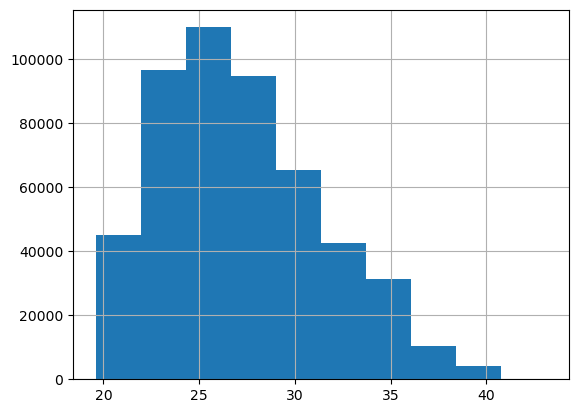

In [25]:
cdf["player_age"].hist()

In [26]:
# provide an index for playerID
cdf["player_idx"], player_lookup = define_index(cdf, "personId")

/tmp/ipykernel_244829/2103138066.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return data[label].replace(lookup_dict).values + 1, lookup_dict


In [27]:
# provide an index for teamID
cdf["team_idx"], team_lookup = define_index(cdf, "teamId")
# provide an index for hometeamID (court factor)
cdf["court_idx"], hometeam_lookup = define_index(cdf, "homeTeamId")
# provide an index for hometeamID (court factor)
cdf["season_idx"], season_lookup = define_index(cdf, "SEASON")
# provide an index for shot type
cdf["subType_idx"], subType_lookup = define_index(cdf, "subType")
cdf["shot_type_idx"], shot_type_lookup = define_index(cdf, "shot_type")
# positin
cdf["position_idx"], position_lookup = define_index(cdf, "POSITION")
# team defense
cdf["def_idx"], def_team_lookup = define_index(cdf, "defTeamId")

/tmp/ipykernel_244829/2103138066.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return data[label].replace(lookup_dict).values + 1, lookup_dict
/tmp/ipykernel_244829/2103138066.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return data[label].replace(lookup_dict).values + 1, lookup_dict
/tmp/ipykernel_244829/2103138066.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to

In [28]:
cdf = cdf.reset_index(drop=True)

In [ ]:
data_model=cdf[['gameId','event_id','actionId','actionNumber','description',
                'is_made','SHOT_DISTANCE','ANGLE','xLegacy','yLegacy','shotValue', # shot info
                'subType','subType_idx','shot_type','shot_type_idx', # shot categorical info
                'SEASON','season_idx', # season
                'PLAYER','PLAYER_ID','player_age','HEIGHT_INCHES', 'player_idx' # player info
                'POSITION','position_idx', # positional info
                'homeTeamId','homeTeamTricode','court_idx', # home team info
                'awayTeamId','awayTeamTricode',
                'defTeamId','defTeamTricode','def_idx', # defensive team info
                'score_shooter','score_opposition','score_diff', # score info
                'period','time_minutes','time_seconds', # time info
                'ishome_shooter','teamId','teamTricode' # shooter team Info
                ]].reset_index(drop=True)
cdf.columns.difference(data_model.columns)

Index(['AGE', 'BIRTH_DATE', 'GAME_ID', 'SCHOOL', 'TeamID', 'actionType',
       'birthdate', 'clock', 'isFieldGoal', 'location', 'minutes', 'personId',
       'playerName', 'playerNameI', 'player_idx', 'pointsTotal', 'scoreAway',
       'scoreAway_mod', 'scoreAway_mod_fill', 'scoreHome', 'scoreHome_mod',
       'scoreHome_mod_fill', 'season_date', 'season_end_year', 'seconds',
       'shotDistance', 'shotResult', 'team_idx', 'videoAvailable'],
      dtype='object')

In [30]:
X = data_model.loc[:, data_model.columns != 'is_made']
y = data_model['is_made']
idx = np.arange(len(X))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X, y, idx, test_size=0.33, random_state=RANDOM_SEED)
data_model['is_train'] = data_model.index.isin(idx_train).astype(int)
data_model.head()

,gameId,event_id,actionId,actionNumber,description,is_made,SHOT_DISTANCE,ANGLE,xLegacy,yLegacy,shotValue,subType,subType_idx,shot_type,shot_type_idx,SEASON,season_idx,PLAYER,PLAYER_ID,player_age,HEIGHT_INCHES,POSITION,position_idx,homeTeamId,homeTeamTricode,court_idx,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,def_idx,score_shooter,score_opposition,score_diff,period,time_minutes,time_seconds,ishome_shooter,teamId,teamTricode,is_train
0,22200001,0,3,7,MISS Embiid 13' Turnaround Fadeaway Shot,0,12.815615,67.036227,-118,50,2,Turnaround Fadeaway shot,1,JUMPER,1,2022-23,1,Joel Embiid,203954.0,29.374401,84.0,C-F,1,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,0.0,0.0,0.0,1,11.633333,698.0,0,1610612755,PHI,1
1,22200001,1,7,11,Smart 13' Driving Floating Bank Jump Shot (2 PTS),1,13.200379,65.376435,120,55,2,Driving Floating Bank Jump Shot,2,JUMPER,1,2022-23,1,Marcus Smart,203935.0,29.401780,76.0,G,2,1610612738.0,BOS,1,1.610613e+09,PHI,1610612755.0,PHI,2,2.0,0.0,2.0,1,11.250000,675.0,1,1610612738,BOS,1
2,22200001,2,8,12,MISS Harris 14' Driving Floating Jump Shot,0,14.396180,20.323137,50,135,2,Driving Floating Jump Shot,3,JUMPER,1,2022-23,1,Tobias Harris,202699.0,31.041752,79.0,F,3,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,0.0,2.0,-2.0,1,11.083333,665.0,0,1610612755,PHI,0
3,22200001,3,10,14,Harris Tip Layup Shot (2 PTS),1,0.000000,0.000000,0,0,2,Tip Layup Shot,4,LAYUP,2,2022-23,1,Tobias Harris,202699.0,31.041752,79.0,F,3,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,2.0,2.0,0.0,1,11.050000,663.0,0,1610612755,PHI,1
4,22200001,4,11,15,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),1,23.711811,78.074008,-232,49,3,Jump Shot,5,JUMPER,1,2022-23,1,Jayson Tatum,1628369.0,25.409993,80.0,F-G,4,1610612738.0,BOS,1,1.610613e+09,PHI,1610612755.0,PHI,2,5.0,2.0,3.0,1,10.766667,646.0,1,1610612738,BOS,1


In [31]:
bart_features = ['SHOT_DISTANCE','ANGLE']
bart_mm_scaler = MinMaxScaler()
X_train[['distance_mm', 'angle_mm']] = bart_mm_scaler.fit_transform(X_train[['SHOT_DISTANCE', 'ANGLE']])
X_test[['distance_mm', 'angle_mm']] = bart_mm_scaler.transform(X_test[['SHOT_DISTANCE', 'ANGLE']])
data_model.loc[idx_train, ['distance_mm', 'angle_mm']] = X_train[['distance_mm', 'angle_mm']]
data_model.loc[idx_test, ['distance_mm', 'angle_mm']] = X_test[['distance_mm', 'angle_mm']]

In [32]:
data_model.head()

,gameId,event_id,actionId,actionNumber,description,is_made,SHOT_DISTANCE,ANGLE,xLegacy,yLegacy,shotValue,subType,subType_idx,shot_type,shot_type_idx,SEASON,season_idx,PLAYER,PLAYER_ID,player_age,HEIGHT_INCHES,POSITION,position_idx,homeTeamId,homeTeamTricode,court_idx,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,def_idx,score_shooter,score_opposition,score_diff,period,time_minutes,time_seconds,ishome_shooter,teamId,teamTricode,is_train,distance_mm,angle_mm
0,22200001,0,3,7,MISS Embiid 13' Turnaround Fadeaway Shot,0,12.815615,67.036227,-118,50,2,Turnaround Fadeaway shot,1,JUMPER,1,2022-23,1,Joel Embiid,203954.0,29.374401,84.0,C-F,1,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,0.0,0.0,0.0,1,11.633333,698.0,0,1610612755,PHI,1,0.267300,0.670484
1,22200001,1,7,11,Smart 13' Driving Floating Bank Jump Shot (2 PTS),1,13.200379,65.376435,120,55,2,Driving Floating Bank Jump Shot,2,JUMPER,1,2022-23,1,Marcus Smart,203935.0,29.401780,76.0,G,2,1610612738.0,BOS,1,1.610613e+09,PHI,1610612755.0,PHI,2,2.0,0.0,2.0,1,11.250000,675.0,1,1610612738,BOS,1,0.275325,0.653883
2,22200001,2,8,12,MISS Harris 14' Driving Floating Jump Shot,0,14.396180,20.323137,50,135,2,Driving Floating Jump Shot,3,JUMPER,1,2022-23,1,Tobias Harris,202699.0,31.041752,79.0,F,3,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,0.0,2.0,-2.0,1,11.083333,665.0,0,1610612755,PHI,0,0.300267,0.203268
3,22200001,3,10,14,Harris Tip Layup Shot (2 PTS),1,0.000000,0.000000,0,0,2,Tip Layup Shot,4,LAYUP,2,2022-23,1,Tobias Harris,202699.0,31.041752,79.0,F,3,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,2.0,2.0,0.0,1,11.050000,663.0,0,1610612755,PHI,1,0.000000,0.000000
4,22200001,4,11,15,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),1,23.711811,78.074008,-232,49,3,Jump Shot,5,JUMPER,1,2022-23,1,Jayson Tatum,1628369.0,25.409993,80.0,F-G,4,1610612738.0,BOS,1,1.610613e+09,PHI,1610612755.0,PHI,2,5.0,2.0,3.0,1,10.766667,646.0,1,1610612738,BOS,1,0.494566,0.780882


In [33]:
data_model.to_csv('input/data_model.csv',index=False)
cdf.to_csv('input/clean_data.csv',index=False)

In [34]:
joblib.dump(bart_mm_scaler, 'minmax_scaler.pkl')

['minmax_scaler.pkl']

In [35]:
# ripped from stackoverflow
def draw_court():
    """ draw_court draws an NBA halfcourt
    
    Returns:
    
        fig (matplotlib.figure.Figure): Figure object visualizing
            an NBA court
    """

    fig = plt.figure(figsize=(9, 9))
    axis = fig.add_subplot(111, aspect='auto')

    plt.plot([-250, 250], [-40, -40], 'k-',zorder=2) # endline
    plt.plot([-250, 250], [430, 430], 'k-',zorder=2) # halfcourt line
    plt.plot([-250, -250], [-40, 430], 'k-',zorder=2) # sideline
    plt.plot([250, 250], [-40, 430], 'k-',zorder=2) # sideline
    
    plt.plot([-30, 30], [-10, -10], 'k-',zorder=2) # backboard
    plt.plot([-60, -60], [-40, 150], 'k-',zorder=2) # lane
    plt.plot([60, 60], [-40, 150], 'k-',zorder=2) # lane
    plt.plot([-80, -80], [-40, 150], 'k-',zorder=2) # lane
    plt.plot([80, 80], [-40, 150], 'k-',zorder=2) # lane
    plt.plot([-80, 80], [150, 150], 'k-',zorder=2) # foul line

    plt.plot([220, 220], [-40, 90], 'k-',zorder=2) # 3pt straight
    plt.plot([-220, -220], [-40, 90], 'k-',zorder=2) # 3pt straight

    three_point = Arc((0, 0), width=237.5*2, height=237.5*2, theta1=22, theta2=158, linewidth=1.5,zorder=2)
    top_key = Arc((0, 150), width=60*2, height=60*2, theta1=0, theta2=180, linewidth=1.5,zorder=2)
    bottom_key = Arc((0, 150), width=60*2, height=60*2, theta1=180, theta2=360, linewidth=1.5, linestyle='--',zorder=2)
    basket = Arc((0, 0), width=7.5*2, height=7.5*2, theta1=0, theta2=360, linewidth=1.5,zorder=2)
    restricted = Arc((0, 7.5), width=40*2, height=40*2, theta1=0, theta2=180, linewidth=1.5,zorder=2)
    half_court = Arc((0, 430), width=60*2, height=60*2, theta1=180, theta2=360, linewidth=1.5,zorder=2)

    axis.add_patch(three_point)
    axis.add_patch(top_key)
    axis.add_patch(bottom_key)
    axis.add_patch(basket)
    axis.add_patch(restricted)
    axis.add_patch(half_court)

    plt.ylim(-50, 450)
    axis.set_aspect(1.0)
    plt.axis('off')

    return fig, axis

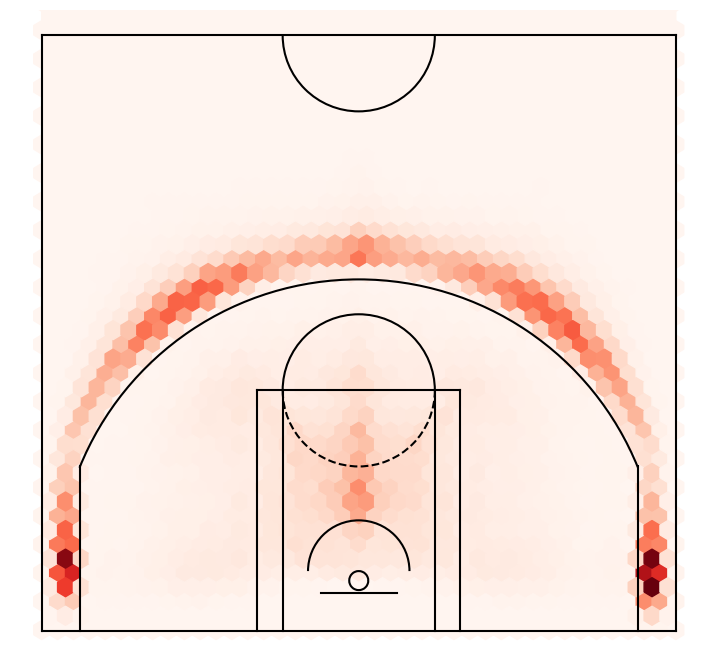

In [36]:
jumps = data_model[data_model["shot_type"] == "JUMPER"]
court, ax = draw_court()
ax.hexbin(
    -jumps["xLegacy"],
    jumps["yLegacy"],
    gridsize=40,
    cmap="Reds",
    zorder=1
)
plt.show()

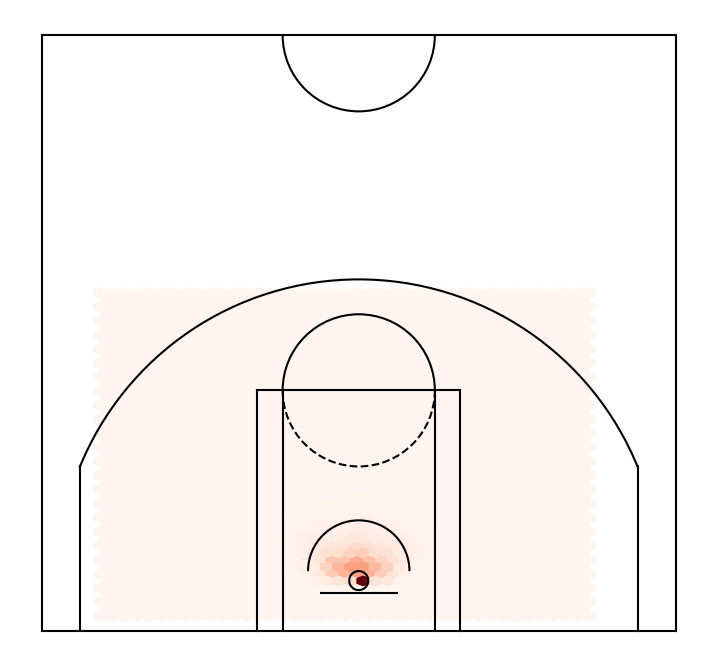

In [37]:
jumps = data_model[data_model["shot_type"] == "LAYUP"]
court, ax = draw_court()
ax.hexbin(
    -jumps["xLegacy"],
    jumps["yLegacy"],
    gridsize=40,
    cmap="Reds",
    zorder=1
)
plt.show()

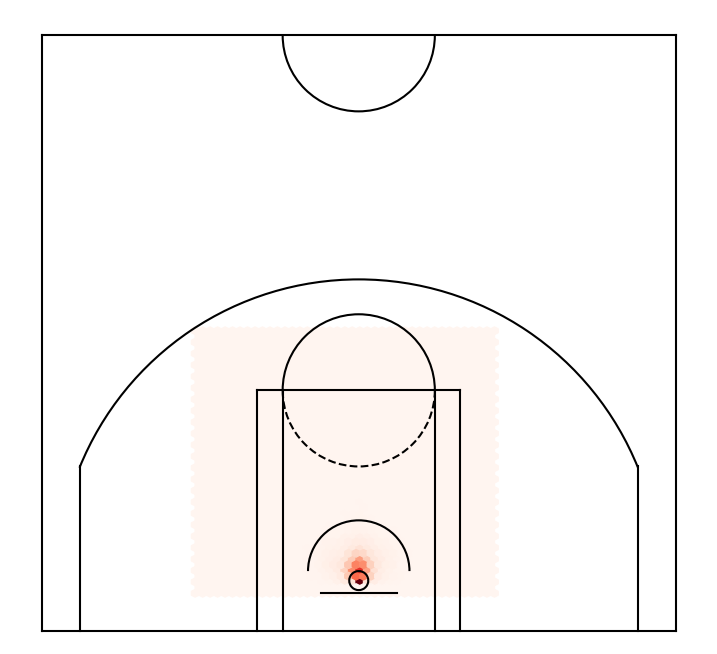

In [38]:
jumps = data_model[data_model["shot_type"] == "DUNK"]
court, ax = draw_court()
ax.hexbin(
    -jumps["xLegacy"],
    jumps["yLegacy"],
    gridsize=40,
    cmap="Reds",
    zorder=1
)
plt.show()

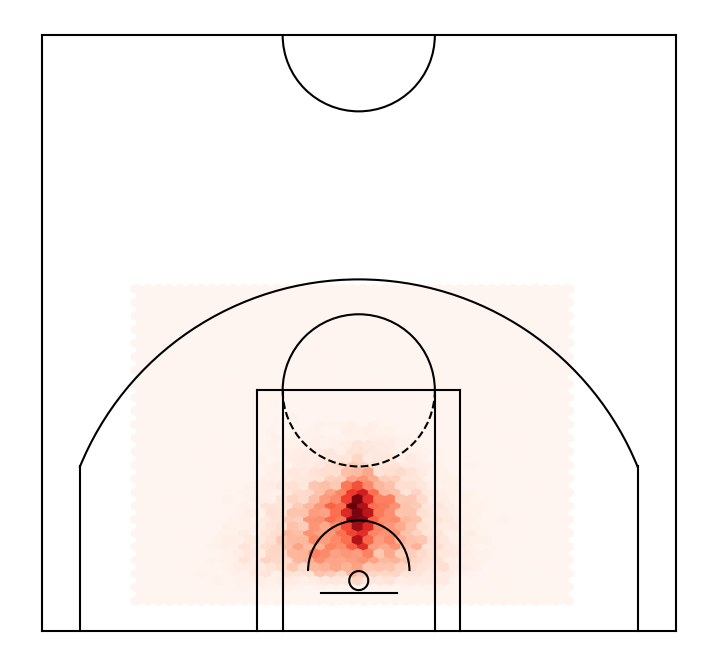

In [39]:
jumps = data_model[data_model["shot_type"] == "HOOK"]
court, ax = draw_court()
ax.hexbin(
    -jumps["xLegacy"],
    jumps["yLegacy"],
    gridsize=40,
    cmap="Reds",
    zorder=1
)
plt.show()

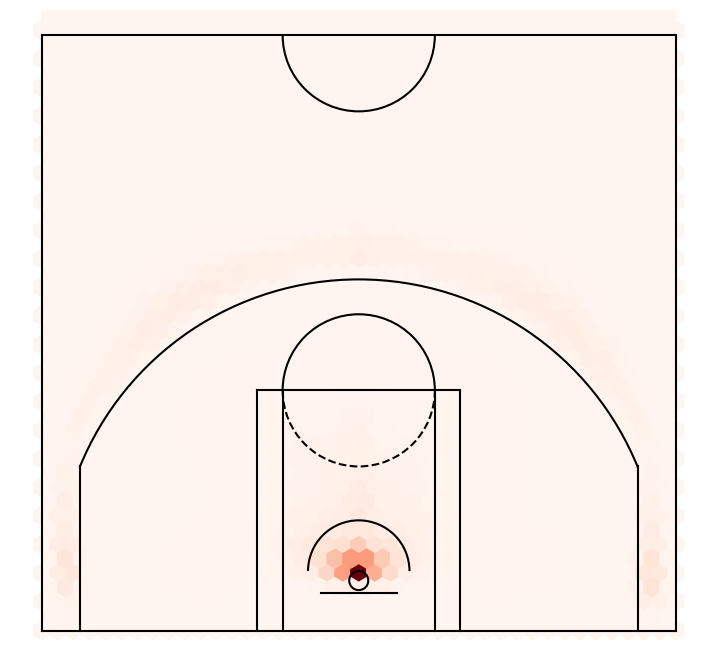

In [40]:
court, ax = draw_court()
ax.hexbin(
    -data_model["xLegacy"],
    data_model["yLegacy"],
    gridsize=40,
    cmap="Reds",
    zorder=1
)
plt.show()